# 风速降尺度算法对比

本笔记本读取 `test_data/` 目录下的风速测试数据，运行 `src/` 目录中的修改后算法，
加载官方预期结果，并生成四幅对比图：

1. 原始输入风速场
2. 修改后算法输出结果
3. 官方预期结果（KGO）
4. 原算法输出结果

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import xarray as xr

try:
    import matplotlib.pyplot as plt

    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 设置中文字体
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

except ImportError as exc:
    raise ImportError('matplotlib is required to display the comparison plots.') from exc

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
ROOT_DIR = PROJECT_DIR.parent
RESOURCE_DIR = PROJECT_DIR / 'test_data' / 'wind_calculations_data'
NORMALIZED_DIR = RESOURCE_DIR / 'normalized_meb6d'
# ORIGINAL_PROJECT_DIR = ROOT_DIR / 'improver-1.18.7'
ORIGINAL_RESULT_PATH = (NORMALIZED_DIR / 'original_algorithm_result.nc') if (NORMALIZED_DIR / 'original_algorithm_result.nc').exists() else (RESOURCE_DIR / 'original_algorithm_result.nc')
MODEL_RESOLUTION = 1500.0

sys.path.insert(0, str(ROOT_DIR))
# sys.path.insert(0, str(ORIGINAL_PROJECT_DIR))

# 导入修改后的算法
from wind_calculations.src.wind_downscaling import RoughnessCorrection

def _select_first_data_var(dataset):
    for name in dataset.data_vars:
        return name
    raise ValueError('No data variables were found in the NetCDF file.')

def load_grid(path: Path) -> np.ndarray:
    try:
        import xarray as xr
    except ImportError:
        xr = None

    if xr is not None:
        dataset = xr.open_dataset(path)
        try:
            var_name = _select_first_data_var(dataset)
            data = dataset[var_name].values
        finally:
            dataset.close()
        return np.asarray(data).squeeze()

    try:
        from netCDF4 import Dataset
    except ImportError:
        Dataset = None

    if Dataset is not None:
        with Dataset(path) as dataset:
            for _, variable in dataset.variables.items():
                if getattr(variable, 'ndim', 0) > 0:
                    return np.asarray(variable[:]).squeeze()
        raise ValueError(f'No array-like variables were found in {path}.')

    try:
        import meteva_base as meb
    except ImportError as exc:
        raise ImportError(
            'This notebook needs one of these readers to load NetCDF data: ' 
            'xarray, netCDF4, or meteva_base.'
        ) from exc

    return np.asarray(meb.read_griddata_from_nc(str(path)).values).squeeze()

def clean_result(data: np.ndarray) -> np.ndarray:
    cleaned = np.asarray(data, dtype=np.float32).copy()
    cleaned = np.nan_to_num(cleaned, nan=0.0, posinf=0.0, neginf=0.0)
    cleaned[cleaned == -32767] = 0.0
    return cleaned

def infer_grid_resolution(data_array) -> float:
    if 'projection_x_coordinate' in data_array.coords and 'projection_y_coordinate' in data_array.coords:
        x_coord = np.asarray(data_array.coords['projection_x_coordinate'].values, dtype=np.float64)
        y_coord = np.asarray(data_array.coords['projection_y_coordinate'].values, dtype=np.float64)
    else:
        x_coord = np.asarray(data_array.coords['lon'].values, dtype=np.float64)
        y_coord = np.asarray(data_array.coords['lat'].values, dtype=np.float64)
    xres = np.abs(np.diff(x_coord)).mean()
    yres = np.abs(np.diff(y_coord)).mean()
    return float((xres + yres) / 2.0)

def run_modified_algorithm(wind_speed: np.ndarray, height_grid: np.ndarray, a_over_s: np.ndarray, 
                         sigma: np.ndarray, pporo: np.ndarray, modoro: np.ndarray, 
                         ppres: float, z0: np.ndarray = None) -> np.ndarray:
    algorithm = RoughnessCorrection(
        a_over_s=a_over_s,
        sigma=sigma,
        pporo=pporo,
        modoro=modoro,
        modres=MODEL_RESOLUTION,
        ppres=ppres,
        z0=z0
    )
    return clean_result(algorithm.process(wind_speed=wind_speed, height_grid=height_grid))


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


注：normalized_meb6d目录下带_6尾缀的数据为经过投影坐标转换为经纬度的数据，因这一转换导致误差偏大，故现不使用该数据，现在使用的数据为仅将投影坐标重命名为lat/lon的数据。

In [2]:
# -*- coding: utf-8 -*-
"""将输入网格数据预处理为 meteva_base 标准六维格式。

处理步骤：
1. 选择目标变量。
2. 若存在投影坐标与 CRS 信息，先将投影坐标转换为经纬度坐标。
3. 重排 / 补齐为六维：member, level, time, dtime, lat, lon。
4. 补齐必要属性并写出 NetCDF。
"""

from __future__ import annotations

import argparse
import sys
import warnings
from pathlib import Path

import numpy as np
import xarray as xr

try:
    from pyproj import CRS, Transformer
except Exception:  # pragma: no cover
    CRS = None
    Transformer = None

_REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
_DEFAULT_ATTRS = {
    "units": None,
    "model": None,
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}


def _pick_data_var(dataset: xr.Dataset, var_name: str | None) -> xr.DataArray:
    """选择要处理的数据变量。"""
    if var_name:
        if var_name not in dataset.data_vars:
            raise ValueError(f"变量 {var_name} 不存在。可选: {list(dataset.data_vars)}")
        return dataset[var_name]

    if not dataset.data_vars:
        raise ValueError("输入文件中没有数据变量。")

    selected_name, selected_var = max(
        dataset.data_vars.items(), key=lambda item: (item[1].ndim, item[1].size)
    )
    print(f"[INFO] 未指定变量，自动选择: {selected_name}")
    return selected_var


def _fill_required_attrs(attrs: dict) -> dict:
    """仅在缺失时补齐 meteva_base 必要属性默认值。"""
    filled = dict(attrs)
    for key, default in _DEFAULT_ATTRS.items():
        if key not in filled or filled[key] is None or filled[key] == "":
            filled[key] = default
    return filled


def _make_netcdf_safe_attrs(attrs: dict) -> dict:
    """将不支持写入 netCDF 的 None 属性值替换为空字符串。"""
    safe = {}
    for key, value in attrs.items():
        safe[key] = "" if value is None else value
    return safe


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> str | None:
    """查找数据变量对应的 grid_mapping 变量名。"""
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm

    for var_name in dataset.data_vars:
        cand = dataset[var_name].attrs.get("grid_mapping")
        if isinstance(cand, str) and cand in dataset.variables:
            return cand
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray) -> Transformer | None:
    """从 CF grid_mapping 构造投影到经纬度的转换器。"""
    if CRS is None or Transformer is None:
        warnings.warn("pyproj 不可用，跳过投影坐标转经纬度。")
        return None

    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None

    gm_var = dataset[grid_mapping_name]
    attrs = dict(gm_var.attrs)
    try:
        if "crs_wkt" in attrs and attrs["crs_wkt"]:
            src_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            src_crs = CRS.from_cf(attrs)
        dst_crs = CRS.from_epsg(4326)
        return Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _convert_projection_to_latlon(
    data: xr.DataArray, dataset: xr.Dataset
) -> tuple[xr.DataArray, bool]:
    """将 projection_x/y_coordinate 转换为 lat/lon（若可行）。"""
    dims = tuple(data.dims)
    if "projection_y_coordinate" not in dims or "projection_x_coordinate" not in dims:
        return data, False

    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False

    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)

    lat_1d = np.nanmean(lat2d, axis=1)
    lon_1d = np.nanmean(lon2d, axis=0)

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    )
    out = out.assign_coords(
        lat=("lat", lat_1d.astype(np.float64)),
        lon=("lon", lon_1d.astype(np.float64)),
    )
    out_attrs = dict(out.attrs)
    out_attrs.pop("grid_mapping", None)
    out.attrs = out_attrs
    return out, True


def _rename_projection_to_latlon(data: xr.DataArray) -> tuple[xr.DataArray, bool]:
    """仅重命名投影坐标维度为 lat/lon，不做投影坐标转换。"""
    dims = tuple(data.dims)
    if "projection_y_coordinate" not in dims or "projection_x_coordinate" not in dims:
        return data, False

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    )
    out_attrs = dict(out.attrs)
    out_attrs.pop("grid_mapping", None)
    out.attrs = out_attrs
    return out, True


def _normalize_dims(
    data: xr.DataArray, dataset: xr.Dataset, coord_mode: str = "convert"
) -> xr.DataArray:
    """将数据整理为 meteva_base 标准六维。"""
    if coord_mode == "convert":
        data, _ = _convert_projection_to_latlon(data, dataset)
    elif coord_mode == "rename":
        data, _ = _rename_projection_to_latlon(data)
    else:
        raise ValueError("coord_mode must be 'rename' or 'convert'")
    dims = tuple(data.dims)

    rename_map: dict[str, str] = {}
    if "latitude" in dims and "lat" not in dims:
        rename_map["latitude"] = "lat"
    if "longitude" in dims and "lon" not in dims:
        rename_map["longitude"] = "lon"
    if "y" in dims and "lat" not in dims:
        rename_map["y"] = "lat"
    if "x" in dims and "lon" not in dims:
        rename_map["x"] = "lon"
    if rename_map:
        data = data.rename(rename_map)
        dims = tuple(data.dims)

    if data.ndim == 2:
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(y_name, x_name)
        if y_name != "lat" or x_name != "lon":
            data = data.rename({y_name: "lat", x_name: "lon"})
    elif data.ndim == 3:
        level_name = "level" if "level" in dims else dims[0]
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(level_name, y_name, x_name)
        rename_3d = {}
        if level_name != "level":
            rename_3d[level_name] = "level"
        if y_name != "lat":
            rename_3d[y_name] = "lat"
        if x_name != "lon":
            rename_3d[x_name] = "lon"
        if rename_3d:
            data = data.rename(rename_3d)
    elif data.ndim == 6 and set(dims) == set(_REQUIRED_DIMS):
        data = data.transpose(*_REQUIRED_DIMS)
    else:
        raise ValueError(
            f"暂不支持维度 {dims}（ndim={data.ndim}）。请先整理为 2D、3D 或标准 6D。"
        )

    if "member" not in data.dims:
        data = data.expand_dims({"member": ["data0"]})
    if "level" not in data.dims:
        data = data.expand_dims({"level": [0.0]})
    if "time" not in data.dims:
        data = data.expand_dims({"time": [np.datetime64("1970-01-01T00:00:00")]})
    if "dtime" not in data.dims:
        data = data.expand_dims({"dtime": [0]})

    data = data.transpose(*_REQUIRED_DIMS)
    data.attrs = _fill_required_attrs(dict(data.attrs))
    return rebuild_to_meb_griddata(np.asarray(data.values, dtype=np.float32), data)


def preprocess_to_meb6d(
    input_path: str,
    output_path: str,
    var_name: str | None = None,
    coord_mode: str = "convert",
) -> None:
    """执行预处理并写出结果。"""
    ds = xr.open_dataset(input_path, decode_timedelta=False)
    data = _pick_data_var(ds, var_name)
    merged_attrs = dict(data.attrs)
    if (
        ("model" not in merged_attrs or merged_attrs.get("model") in (None, ""))
        and "mosg__model_configuration" in ds.attrs
    ):
        merged_attrs["model"] = ds.attrs.get("mosg__model_configuration")

    data = data.copy()
    data.attrs = _fill_required_attrs(merged_attrs)
    normalized = _normalize_dims(data, ds, coord_mode=coord_mode).astype(
        np.float32, copy=False
    )
    normalized.name = data.name or "data"
    normalized.attrs = _make_netcdf_safe_attrs(dict(normalized.attrs))

    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(out_path)
    print(f"[OK] 写出标准六维文件: {out_path}")
    print(f"[OK] 输出维度: {normalized.dims}")

# 预处理：将官方测试数据标准化为 meteva_base 六维格式
RUN_PREPROCESS = False
PREPROCESS_COORD_MODE = "rename"  # 可选: "rename" 或 "convert"

NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

normalize_tasks = [
    ("input.nc", "input.nc"),
    ("a_over_s.nc", "a_over_s.nc"),
    ("sigma.nc", "sigma.nc"),
    ("highres_orog.nc", "highres_orog.nc"),
    ("standard_orog.nc", "standard_orog.nc"),
    ("kgo.nc", "kgo.nc"),
    ("original_algorithm_result.nc", "original_algorithm_result.nc"),
    ("original_cli_result.nc", "original_cli_result.nc"),
]

veg_file = RESOURCE_DIR / "veg.nc"
if veg_file.exists():
    normalize_tasks.append(("veg.nc", "veg.nc"))


def pick_var_name(nc_path: Path) -> str:
    ds = xr.open_dataset(nc_path)
    try:
        if not ds.data_vars:
            raise ValueError(f"文件中未找到数据变量: {nc_path}")
        return str(max(ds.data_vars, key=lambda n: (ds[n].ndim, ds[n].size)))
    finally:
        ds.close()


if RUN_PREPROCESS:
    for src_name, dst_name in normalize_tasks:
        src_path = RESOURCE_DIR / src_name
        dst_path = NORMALIZED_DIR / dst_name
        var_name = pick_var_name(src_path)
        print(f"处理: {src_name} -> {dst_name} (var={var_name}, mode={PREPROCESS_COORD_MODE})")
        preprocess_to_meb6d(
            str(src_path),
            str(dst_path),
            var_name=var_name,
            coord_mode=PREPROCESS_COORD_MODE,
        )
    print("预处理完成，输出目录:", NORMALIZED_DIR)
else:
    print("跳过预处理（RUN_PREPROCESS=False），输出目录:", NORMALIZED_DIR)


跳过预处理（RUN_PREPROCESS=False），输出目录: d:\workspace\improver\wind_calculations\test_data\wind_calculations_data\normalized_meb6d


### 数据读取

In [3]:
import xarray as xr

def load_da(path: Path):
    ds = xr.open_dataset(path)
    try:
        var_name = _select_first_data_var(ds)
        da = ds[var_name].load()
    finally:
        ds.close()
    return da

# 读取测试数据（统一使用 xarray）
print("正在读取测试数据...")

# 风速输入数据
wind_speed_file = NORMALIZED_DIR / 'input.nc'
wind_speed_da = load_da(wind_speed_file)
wind_speed_values = np.asarray(wind_speed_da.values).squeeze()

# 地形轮廓粗糙度
a_over_s_file = NORMALIZED_DIR / 'a_over_s.nc'
a_over_s_da = load_da(a_over_s_file)
a_over_s = np.asarray(a_over_s_da.values).squeeze()

# 高度标准差
sigma_file = NORMALIZED_DIR / 'sigma.nc'
sigma_da = load_da(sigma_file)
sigma = np.asarray(sigma_da.values).squeeze()

# 高分辨率目标地形
highres_orog_file = NORMALIZED_DIR / 'highres_orog.nc'
highres_orog_da = load_da(highres_orog_file)
pporo = np.asarray(highres_orog_da.values).squeeze()
ppres = infer_grid_resolution(highres_orog_da)

# 源地形（模式地形）
standard_orog_file = NORMALIZED_DIR / 'standard_orog.nc'
standard_orog_da = load_da(standard_orog_file)
modoro = np.asarray(standard_orog_da.values).squeeze()

# 植被粗糙度（可选）
veg_file = NORMALIZED_DIR / 'veg.nc'
if veg_file.exists():
    z0_da = load_da(veg_file)
    z0 = np.asarray(z0_da.values).squeeze()
    print("找到植被粗糙度数据")
else:
    z0_da = None
    z0 = None
    print("未找到植被粗糙度数据")

# 官方预期结果
kgo_file = (NORMALIZED_DIR / 'kgo.nc') if (NORMALIZED_DIR / 'kgo.nc').exists() else (RESOURCE_DIR / 'kgo.nc')
kgo_da = load_da(kgo_file)
kgo_data = np.asarray(kgo_da.values)

#原算法结果
if not ORIGINAL_RESULT_PATH.exists():
    raise FileNotFoundError(
        f'Original algorithm result file was not found: {ORIGINAL_RESULT_PATH}. '
        'Please run improver-1.18.7/original_algorithm/run_original_orographic_enhancement.py first.'
    )
original_result = clean_result(load_grid(ORIGINAL_RESULT_PATH))

print(f"Derived ppres: {ppres:.1f} m")
print(f"Configured model resolution: {MODEL_RESOLUTION:.1f} m")

print(f"风速数据形状: {wind_speed_values.shape}")
print(f"地形轮廓粗糙度形状: {a_over_s.shape}")
print(f"高度标准差形状: {sigma.shape}")
print(f"高分辨率地形形状: {pporo.shape}")
print(f"源地形形状: {modoro.shape}")
print(f"官方预期结果形状: {kgo_data.shape}")
print(f"原算法脚本输出结果形状: {original_result.shape}")

# 获取高度网格
if 'level' in wind_speed_da.coords:
    height_grid = np.asarray(wind_speed_da.coords['level'].values, dtype=np.float32)
elif 'height' in wind_speed_da.coords:
    height_grid = np.asarray(wind_speed_da.coords['height'].values, dtype=np.float32)
else:
    # 默认高度层
    height_grid = np.array([10.0], dtype=np.float32)

正在读取测试数据...
找到植被粗糙度数据
Derived ppres: 2000.0 m
Configured model resolution: 1500.0 m
风速数据形状: (9, 101, 101)
地形轮廓粗糙度形状: (101, 101)
高度标准差形状: (101, 101)
高分辨率地形形状: (101, 101)
源地形形状: (101, 101)
官方预期结果形状: (1, 9, 1, 1, 101, 101)
原算法脚本输出结果形状: (9, 101, 101)


In [4]:
# 统一清洗缺测值和异常值，避免后续绘图或数值计算受影响。
example_wind_speed = clean_result(wind_speed_values)
example_a_over_s = clean_result(a_over_s)
example_sigma = clean_result(sigma)
example_pporo = clean_result(pporo)
example_modoro = clean_result(modoro)
example_z0 = clean_result(z0) if z0_da is not None else None

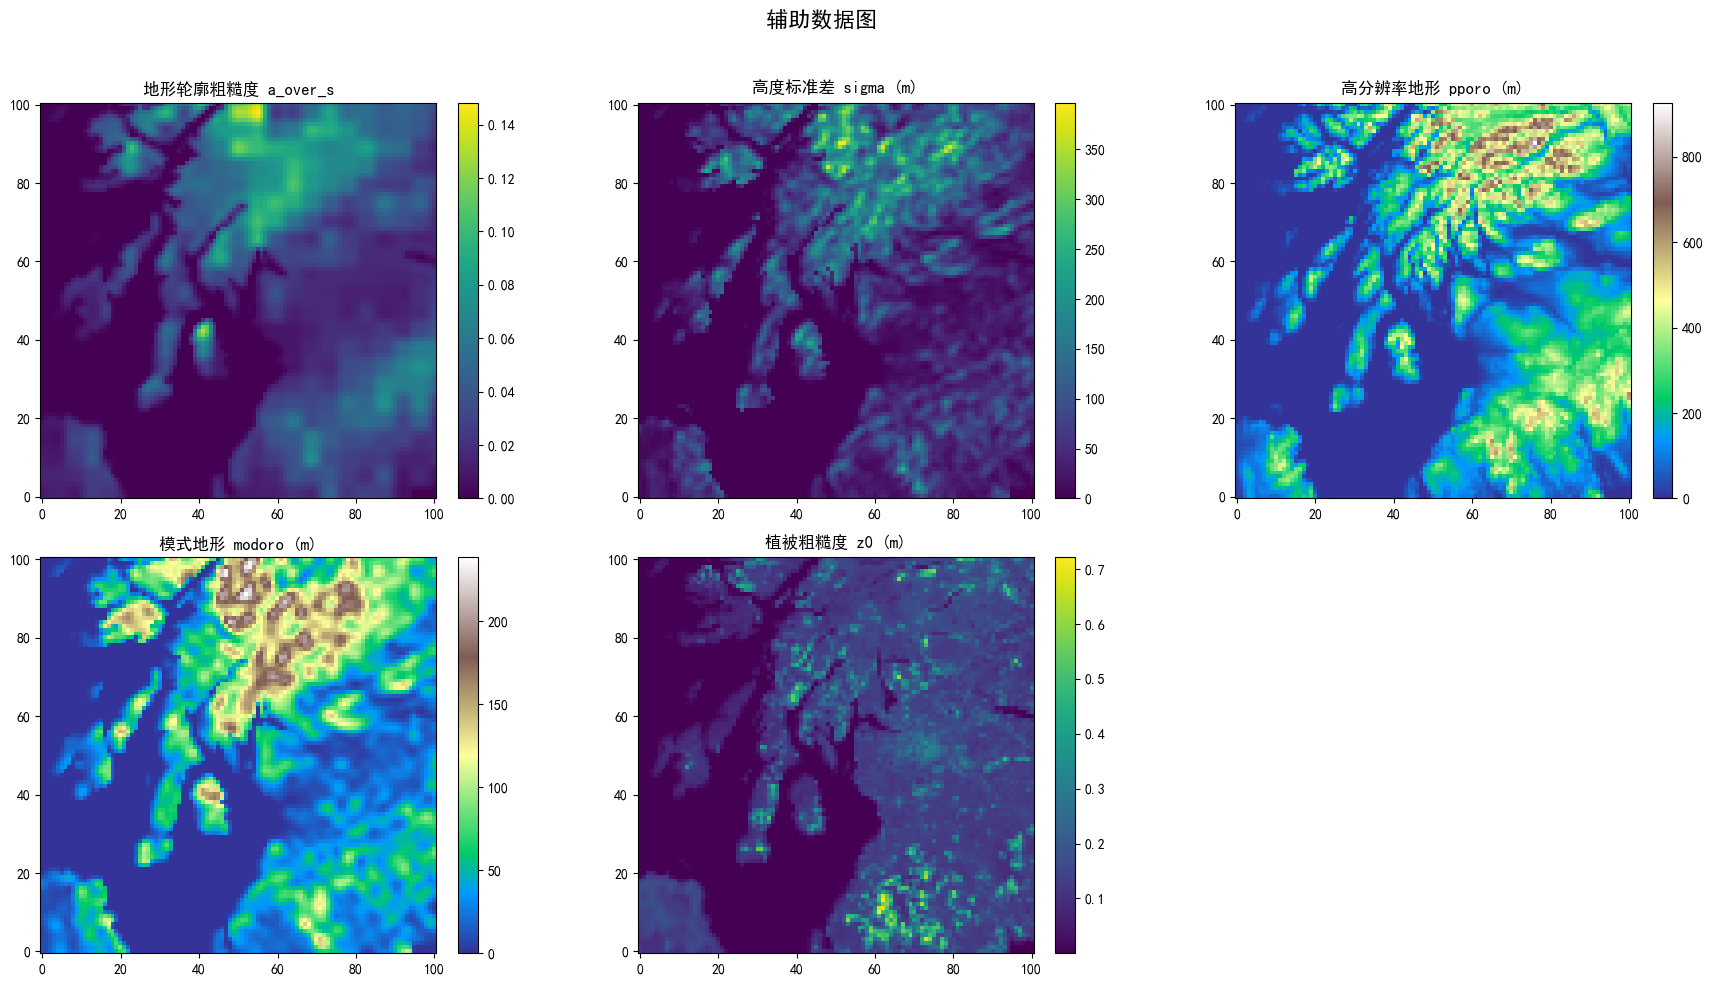

In [5]:
# ========== 辅助数据图 ==========
aux_fields = [
    ('地形轮廓粗糙度 a_over_s', example_a_over_s, 'viridis', None, None),
    ('高度标准差 sigma (m)', example_sigma, 'viridis', None, None),
    ('高分辨率地形 pporo (m)', example_pporo, 'terrain', None, None),
    ('模式地形 modoro (m)', example_modoro, 'terrain', None, None),
]
if example_z0 is not None:
    aux_fields.append(('植被粗糙度 z0 (m)', example_z0, 'viridis', None, None))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, (title, data, cmap, vmin, vmax) in zip(axes, aux_fields):
    im = ax.imshow(data, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(aux_fields):]:
    ax.axis('off')

fig.suptitle('辅助数据图', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 算法调用

In [6]:
# 运行修改后的算法（输入为np数组）
print("正在运行修改后的风速降尺度算法...")
algorithm_np = RoughnessCorrection(
    a_over_s=a_over_s,
    sigma=sigma,
    pporo=pporo,
    modoro=modoro,
    modres=MODEL_RESOLUTION,
    ppres=ppres,
    z0=z0
)
modified_result = clean_result(algorithm_np.process(wind_speed=wind_speed_values, height_grid=height_grid))

# 读取原算法脚本输出结果
print(f"正在读取原算法脚本输出结果: {ORIGINAL_RESULT_PATH}")

print(f"修改后算法结果形状: {modified_result.shape}")
print(f"原算法结果形状: {original_result.shape}")
print(f"官方预期结果形状: {kgo_data.shape}")

正在运行修改后的风速降尺度算法...
正在读取原算法脚本输出结果: d:\workspace\improver\wind_calculations\test_data\wind_calculations_data\normalized_meb6d\original_algorithm_result.nc
修改后算法结果形状: (9, 101, 101)
原算法结果形状: (9, 101, 101)
官方预期结果形状: (1, 9, 1, 1, 101, 101)


In [7]:
#输入数据为meteva_base网格数据格式
algorithm = RoughnessCorrection(
    a_over_s=a_over_s_da,
    sigma=sigma_da,
    pporo=highres_orog_da,
    modoro=standard_orog_da,
    modres=MODEL_RESOLUTION,
    z0=z0_da
    )
result=algorithm.process(wind_speed=wind_speed_da, height_grid=height_grid)

In [8]:
from wind_calculations.utils.utils import check_for_meb_griddata
check_for_meb_griddata(result)

<xarray.DataArray 'wind_speed' (member: 1, level: 9, time: 1, dtime: 1,
                                lat: 101, lon: 101)> Size: 367kB
array([[[[[[ 6.556671 ,  6.0639687,  7.264569 , ...,  8.778099 ,
            10.054859 , 11.198049 ],
           [ 6.1577373,  6.4452353,  7.109695 , ...,  9.065602 ,
             9.9539995, 10.787956 ],
           [ 6.791712 ,  7.7032623,  8.4231415, ...,  8.042693 ,
             8.712519 ,  9.118112 ],
           ...,
           [10.653563 , 10.806147 , 10.922652 , ..., 12.552111 ,
            13.223808 , 12.328266 ],
           [10.794726 , 10.851562 , 10.842747 , ..., 11.528781 ,
            12.856884 , 15.299269 ],
           [10.755548 , 10.796251 , 10.819544 , ..., 11.91992  ,
            14.660475 , 20.616266 ]]]],



        [[[[11.287148 , 10.631513 , 11.558294 , ..., 11.391409 ,
            12.855132 , 14.291984 ],
           [10.972599 , 10.914226 , 11.3176775, ..., 11.856477 ,
            12.790925 , 13.730508 ],
...
            18.348854 , 18.201336 ],
           [16.41335  , 16.412802 , 16.392435 , ..., 18.693993 ,
            18.651258 , 18.356262 ]]]],



        [[[[23.603945 , 23.545279 , 23.42965  , ..., 29.279123 ,
            28.893862 , 28.334486 ],
           [23.712444 , 23.537363 , 23.317934 , ..., 29.214598 ,
            28.9472   , 28.425346 ],
           [23.73683  , 23.493814 , 23.294268 , ..., 29.048363 ,
            28.97121  , 28.593199 ],
           ...,
           [30.04801  , 30.122269 , 30.204622 , ..., 26.778704 ,
            26.32234  , 26.488792 ],
           [30.116936 , 30.190767 , 30.264494 , ..., 26.70956  ,
            26.49719  , 26.592422 ],
           [30.178137 , 30.251553 , 30.325987 , ..., 26.783142 ,
            26.729416 , 26.803919 ]]]]]],
      shape=(1, 9, 1, 1, 101, 101), dtype=float32)
Coordinates:
  * member   (member) <U5 20B 'data0'
  * level    (level) float32 36B 5.0 50.0 200.0 500.0 ... 3e+03 4e+03 6e+03
  * time     (time) datetime64[us] 8B 1970-01-01
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float64 808B 4e+03 6e+03 8e+03 ... 2e+05 2.02e+05 2.04e+05
  * lon      (lon) float64 808B -2.58e+05 -2.56e+05 ... -6e+04 -5.8e+04
Attributes:
    units:          m s-1
    model:          
    dtime_units:    hour
    level_type:     isobaric
    time_type:      UT
    time_bounds:    [0 0]
    standard_name:  wind_speed
    long_name:      downscaled wind speed

正在生成四幅对比图...


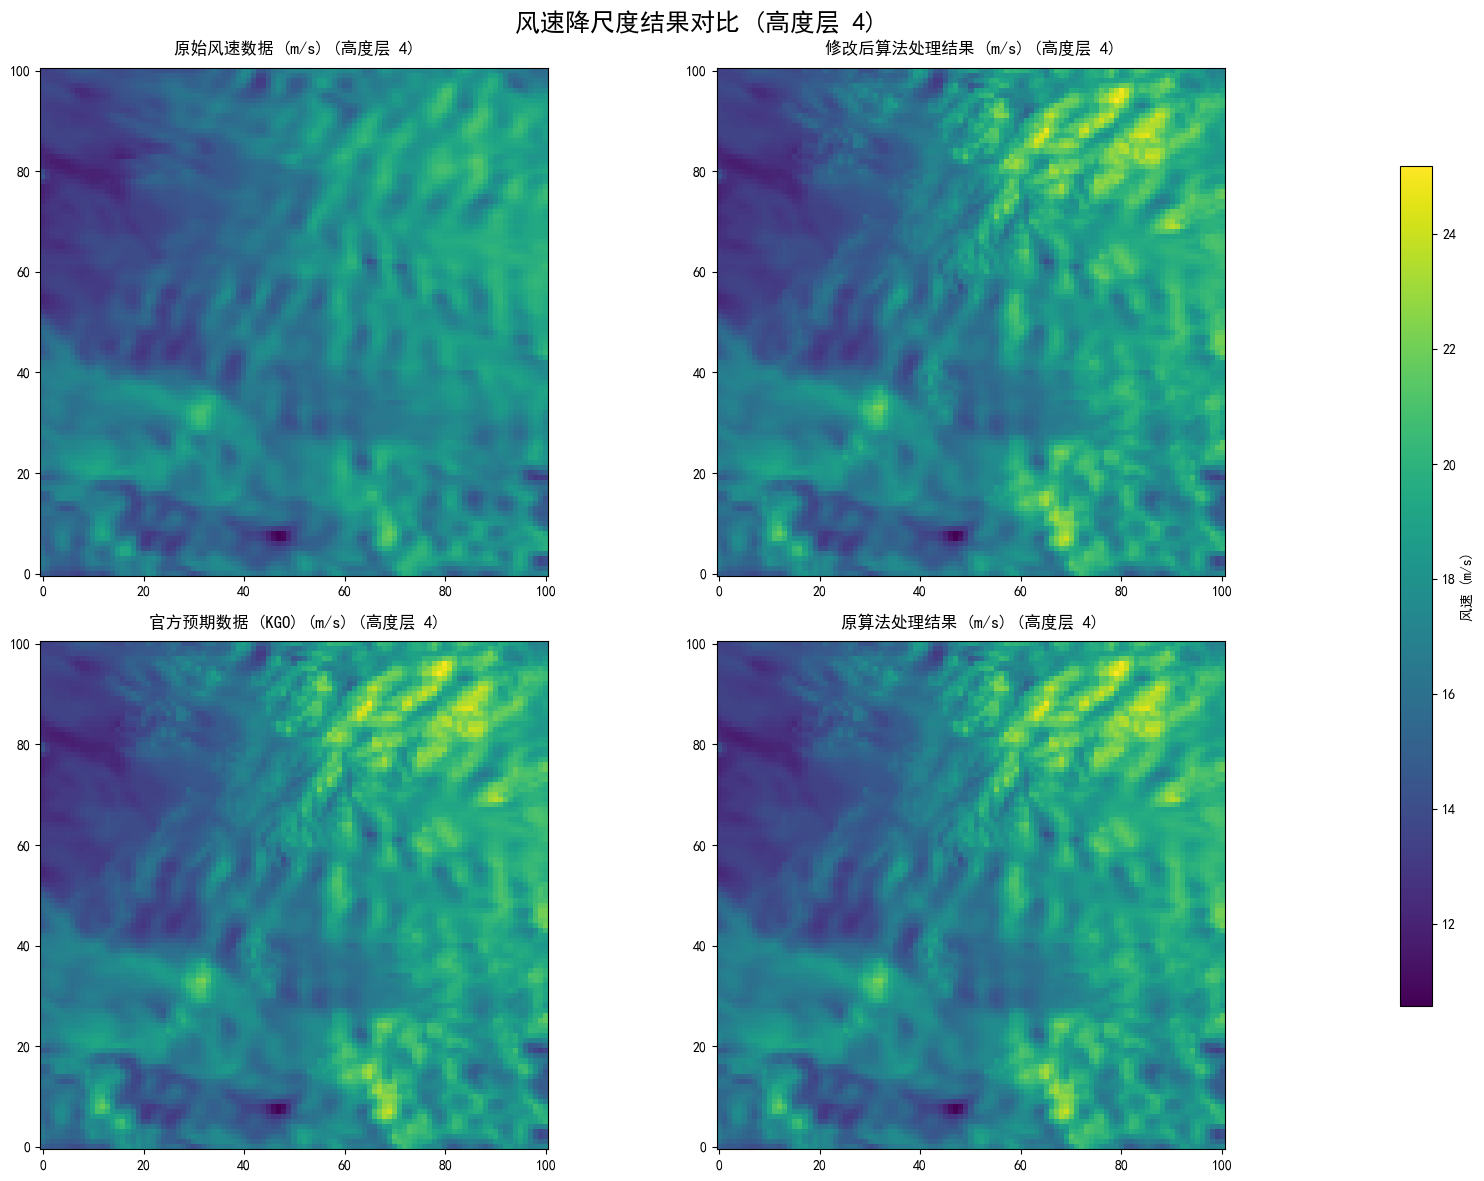


=== 统计对比 ===
原始风速平均值: 16.64 m/s
修改后算法平均值: 17.23 m/s
官方预期平均值: 17.23 m/s
原算法平均值: 17.23 m/s

=== 与官方预期的差异 ===
修改后算法 vs 官方预期 - 平均绝对误差: 0.0000 m/s
修改后算法 vs 原算法 - 平均绝对误差: 0.0000 m/s
原算法 vs 官方预期 - 平均绝对误差: 0.0000 m/s


In [9]:
print("正在生成四幅对比图...")

def _to_plot_ready(arr):
    arr = np.asarray(arr).squeeze()
    if arr.ndim == 2:
        return arr, None
    if arr.ndim == 3:
        return arr, arr.shape[0] // 2
    raise ValueError(f"不支持的绘图数据维度: {arr.shape}")

wind_speed_plot, mid_level = _to_plot_ready(wind_speed_values)
modified_plot, _ = _to_plot_ready(modified_result)
original_plot, _ = _to_plot_ready(original_result)
kgo_plot, _ = _to_plot_ready(kgo_data)

# 选择中间高度层进行可视化（如果有多个高度层）
if mid_level is not None:
    original_data_plot = wind_speed_plot[mid_level]
    modified_result_plot = modified_plot[mid_level]
    original_algorithm_plot = original_plot[mid_level]
    kgo_data_plot = kgo_plot[mid_level]
    plot_title_suffix = f"(高度层 {mid_level})"
else:
    original_data_plot = wind_speed_plot
    modified_result_plot = modified_plot
    original_algorithm_plot = original_plot
    kgo_data_plot = kgo_plot
    plot_title_suffix = ""

# 计算全局最小/最大值，统一颜色范围
all_data = [original_data_plot, modified_result_plot, kgo_data_plot, original_algorithm_plot]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# ========== 调整 figsize 和子图间距 ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # 减小高度，给 colorbar 留空间
fig.suptitle(f'风速降尺度结果对比 {plot_title_suffix}', fontsize=18, y=0.98)  # 标题上移

# 1. 原始风速数据
im1 = axes[0, 0].imshow(original_data_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f'原始风速数据 (m/s) {plot_title_suffix}', fontsize=12, pad=10)

# 2. 修改后的算法处理结果
im2 = axes[0, 1].imshow(modified_result_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f'修改后算法处理结果 (m/s) {plot_title_suffix}', fontsize=12, pad=10)

# 3. 官方预期数据 (KGO)
im3 = axes[1, 0].imshow(kgo_data_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1, 0].set_title(f'官方预期数据 (KGO) (m/s) {plot_title_suffix}', fontsize=12, pad=10)

# 4. 原算法处理结果
im4 = axes[1, 1].imshow(original_algorithm_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f'原算法处理结果 (m/s) {plot_title_suffix}', fontsize=12, pad=10)

# ========== 调整布局，为 colorbar 留出右侧空间 ==========
plt.tight_layout(rect=[0, 0, 0.92, 1])  # 右侧留出 8% 空间给 colorbar

# 添加统一的 colorbar，调整位置和大小
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im4, cax=cbar_ax, label='风速 (m/s)')

plt.show()

# 输出统计信息
print(f"\n=== 统计对比 ===")
print(f"原始风速平均值: {original_data_plot.mean():.2f} m/s")
print(f"修改后算法平均值: {modified_result_plot.mean():.2f} m/s")
print(f"官方预期平均值: {kgo_data_plot.mean():.2f} m/s")
print(f"原算法平均值: {original_algorithm_plot.mean():.2f} m/s")

# 计算差异
diff_modified_official = modified_result_plot - kgo_data_plot
diff_original_official = original_algorithm_plot - kgo_data_plot
diff_midified_original = modified_result_plot - original_algorithm_plot

print(f"\n=== 与官方预期的差异 ===")
print(f"修改后算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_modified_official).mean():.4f} m/s")
print(f"修改后算法 vs 原算法 - 平均绝对误差: {np.abs(diff_midified_original).mean():.4f} m/s")
print(f"原算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_original_official).mean():.4f} m/s")


## CLI 应用
CLI 示例脚本：`wind_calculations/cli/dsc_wind_downscaling.py`

```powershell
python -m wind_calculations.cli.dsc_wind_downscaling
```

输出：`wind_calculations/test_data/wind_calculations_data/normalized_meb6d/cli_test_tmp.nc`（`model_resolution=1500.0` 等参数见脚本底部）。


In [10]:
def load_cli_results():
    """加载CLI结果"""
    import xarray as xr
    from pathlib import Path
    
    modified_cli_path = Path("../test_data/wind_calculations_data/normalized_meb6d/cli_test_tmp.nc")
    original_cli_path = Path("../test_data/wind_calculations_data/normalized_meb6d/original_cli_result.nc")
    
    # 加载修改后算法CLI结果
    modified_cli_ds = xr.open_dataset(modified_cli_path, engine='netcdf4')
    if 'data' in modified_cli_ds:
        modified_cli_result = modified_cli_ds['data'].values
    else:
        for var_name in modified_cli_ds.data_vars:
            modified_cli_result = modified_cli_ds[var_name].values
            break
    
    # 加载原算法CLI结果
    original_cli_ds = xr.open_dataset(original_cli_path, engine='netcdf4')
    if 'data' in original_cli_ds:
        original_cli_result = original_cli_ds['data'].values
    else:
        for var_name in original_cli_ds.data_vars:
            original_cli_result = original_cli_ds[var_name].values
            break
    
    return modified_cli_result.squeeze(), original_cli_result.squeeze()

print("正在加载CLI结果...")
try:
    modified_cli_result, original_cli_result = load_cli_results()
    print(f"✅ CLI结果加载成功")
    print(f"   修改后CLI形状: {modified_cli_result.shape}")
    print(f"   原算法CLI形状: {original_cli_result.shape}")
except Exception as e:
    print(f"❌ CLI结果加载失败: {e}")
    modified_cli_result = None
    original_cli_result = None

正在加载CLI结果...
✅ CLI结果加载成功
   修改后CLI形状: (9, 101, 101)
   原算法CLI形状: (9, 101, 101)


In [11]:
#CLI结果
path="../test_data/wind_calculations_data/normalized_meb6d/cli_test_tmp.nc"
cli_result = xr.open_dataarray(path, engine='netcdf4')
from wind_calculations.utils.utils import check_for_meb_griddata
check_for_meb_griddata(cli_result)

<xarray.DataArray 'wind_speed' (member: 1, level: 9, time: 1, dtime: 1,
                                lat: 101, lon: 101)> Size: 367kB
array([[[[[[ 6.556671, ..., 11.198049],
           ...,
           [10.755548, ..., 20.616266]]]],



        ...,



        [[[[23.603945, ..., 28.334486],
           ...,
           [30.178137, ..., 26.803919]]]]]],
      shape=(1, 9, 1, 1, 101, 101), dtype=float32)
Coordinates:
  * member   (member) <U5 20B 'data0'
  * level    (level) float32 36B 5.0 50.0 200.0 500.0 ... 3e+03 4e+03 6e+03
  * time     (time) datetime64[ns] 8B 1970-01-01
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float64 808B 4e+03 6e+03 8e+03 ... 2e+05 2.02e+05 2.04e+05
  * lon      (lon) float64 808B -2.58e+05 -2.56e+05 ... -6e+04 -5.8e+04
Attributes:
    units:          m s-1
    model:          
    dtime_units:    hour
    level_type:     isobaric
    time_type:      UT
    time_bounds:    [0 0]
    standard_name:  wind_speed
    model_var:      
    long_name:      downscaled wind speed

正在生成插件算法与CLI结果对比图...


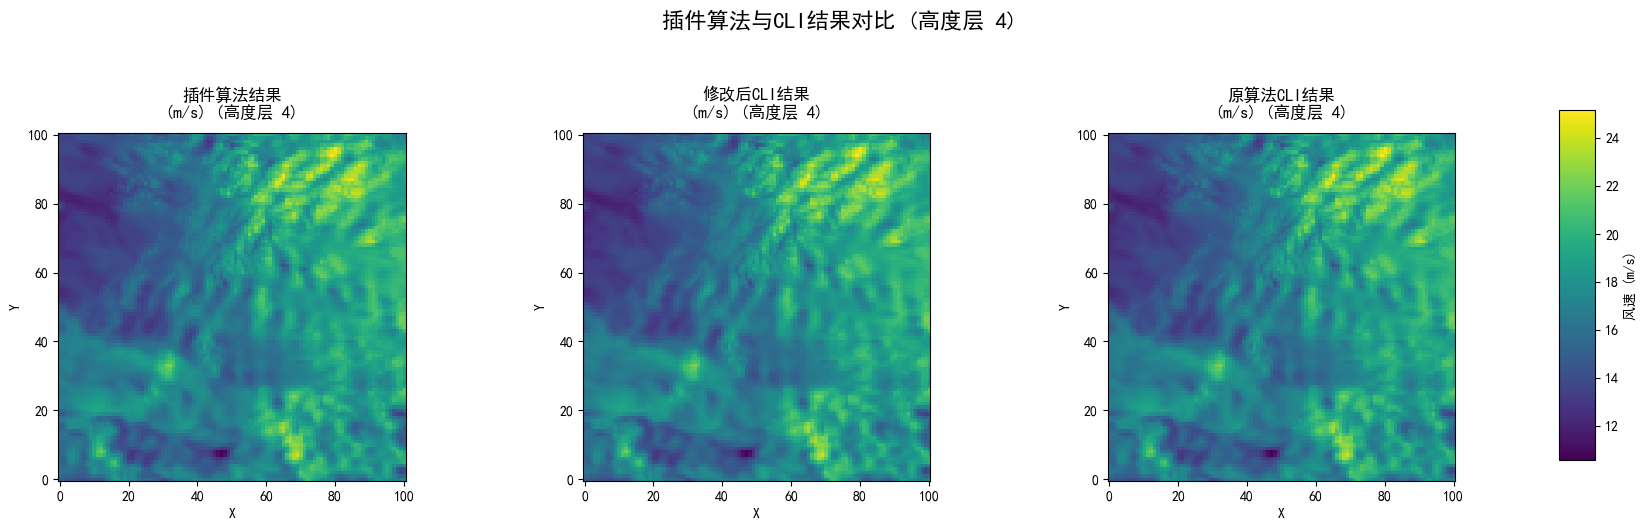


=== 插件算法与CLI结果统计对比 (高度层 4) ===
算法类型                 平均值(m/s)        最大值(m/s)        最小值(m/s)       
-----------------------------------------------------------------
插件算法结果               17.23           25.18           10.58          
修改后CLI结果             17.23           25.18           10.58          
原算法CLI结果             17.23           25.18           10.58          

=== 差异分析 (高度层 4) ===
插件算法 vs 修改后CLI - 平均绝对误差: 0.0000 m/s
插件算法 vs 原算法CLI - 平均绝对误差: 0.0000 m/s
修改后CLI vs 原算法CLI - 平均绝对误差: 0.0000 m/s


In [12]:
print("正在生成插件算法与CLI结果对比图...")

def _to_plot_ready(arr):
    arr = np.asarray(arr).squeeze()
    if arr.ndim == 2:
        return arr, None
    if arr.ndim == 3:
        return arr, arr.shape[0] // 2
    raise ValueError(f"不支持的绘图数据维度: {arr.shape}")

wind_speed_plot, mid_level = _to_plot_ready(wind_speed_values)
modified_plot, _ = _to_plot_ready(modified_result)
modified_cli_plot_all, _ = _to_plot_ready(modified_cli_result)
original_cli_plot_all, _ = _to_plot_ready(original_cli_result)

# 准备数据
if mid_level is not None:
    modified_result_plot = modified_plot[mid_level]
    modified_cli_plot = modified_cli_plot_all[mid_level]
    original_cli_plot = original_cli_plot_all[mid_level]
    plot_title_suffix = f"(高度层 {mid_level})"
else:
    modified_result_plot = modified_plot
    modified_cli_plot = modified_cli_plot_all
    original_cli_plot = original_cli_plot_all
    plot_title_suffix = ""

# 计算三组数据的统一颜色范围
all_data = [modified_result_plot, modified_cli_plot, original_cli_plot]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# ========== 创建1×3水平对比图 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'插件算法与CLI结果对比 {plot_title_suffix}', fontsize=16, y=1.05)

# 1. 插件算法结果
im1 = axes[0].imshow(modified_result_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title(f'插件算法结果\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# 2. 修改后CLI结果
im2 = axes[1].imshow(modified_cli_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title(f'修改后CLI结果\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# 3. 原算法CLI结果
im3 = axes[2].imshow(original_cli_plot, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[2].set_title(f'原算法CLI结果\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

# 紧凑布局
plt.tight_layout()

# 添加垂直colorbar在右侧
plt.subplots_adjust(right=0.88)  # 为colorbar留出右侧空间
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im3, cax=cbar_ax, label='风速 (m/s)')

plt.show()

# ========== 计算并显示统计信息 ==========
print(f"\n=== 插件算法与CLI结果统计对比 {plot_title_suffix} ===")
print(f"{'算法类型':<20} {'平均值(m/s)':<15} {'最大值(m/s)':<15} {'最小值(m/s)':<15}")
print("-" * 65)
print(f"{'插件算法结果':<20} {modified_result_plot.mean():<15.2f} {modified_result_plot.max():<15.2f} {modified_result_plot.min():<15.2f}")
print(f"{'修改后CLI结果':<20} {modified_cli_plot.mean():<15.2f} {modified_cli_plot.max():<15.2f} {modified_cli_plot.min():<15.2f}")
print(f"{'原算法CLI结果':<20} {original_cli_plot.mean():<15.2f} {original_cli_plot.max():<15.2f} {original_cli_plot.min():<15.2f}")

# 计算差异
print(f"\n=== 差异分析 {plot_title_suffix} ===")
diff_plugin_modified_cli = modified_result_plot - modified_cli_plot
diff_plugin_original_cli = modified_result_plot - original_cli_plot
diff_cli_between = modified_cli_plot - original_cli_plot

print(f"插件算法 vs 修改后CLI - 平均绝对误差: {np.abs(diff_plugin_modified_cli).mean():.4f} m/s")
print(f"插件算法 vs 原算法CLI - 平均绝对误差: {np.abs(diff_plugin_original_cli).mean():.4f} m/s")
print(f"修改后CLI vs 原算法CLI - 平均绝对误差: {np.abs(diff_cli_between).mean():.4f} m/s")


正在生成差异对比图...


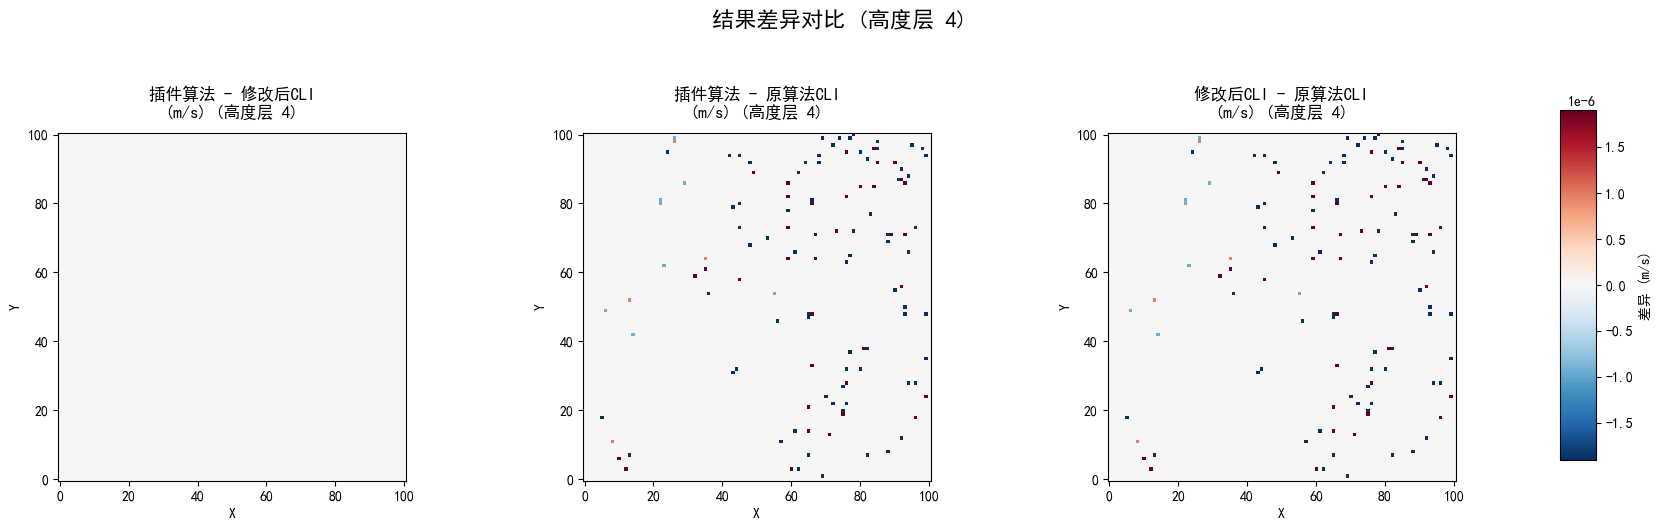

In [13]:
# ========== 绘制差异图 ==========
print("\n正在生成差异对比图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'结果差异对比 {plot_title_suffix}', fontsize=16, y=1.05)

# 计算差异的统一颜色范围
diff_vmax = max(
    np.abs(diff_plugin_modified_cli).max(),
    np.abs(diff_plugin_original_cli).max(),
    np.abs(diff_cli_between).max()
)
diff_vmin = -diff_vmax  # 对称范围，0为中心

# 1. 插件算法 - 修改后CLI
im1 = axes[0].imshow(diff_plugin_modified_cli, cmap='RdBu_r', origin='lower', vmin=diff_vmin, vmax=diff_vmax)
axes[0].set_title(f'插件算法 - 修改后CLI\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# 2. 插件算法 - 原算法CLI
im2 = axes[1].imshow(diff_plugin_original_cli, cmap='RdBu_r', origin='lower', vmin=diff_vmin, vmax=diff_vmax)
axes[1].set_title(f'插件算法 - 原算法CLI\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# 3. 修改后CLI - 原算法CLI
im3 = axes[2].imshow(diff_cli_between, cmap='RdBu_r', origin='lower', vmin=diff_vmin, vmax=diff_vmax)
axes[2].set_title(f'修改后CLI - 原算法CLI\n(m/s) {plot_title_suffix}', fontsize=12, pad=10)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

# 紧凑布局
plt.tight_layout()
plt.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(im3, cax=cbar_ax, label='差异 (m/s)')

plt.show()